# Datathon 2026 - Raw Data EDA

This notebook performs exploratory data analysis on the Kaggle raw files with focus on:
- data quality and table coverage
- sales behavior (`Revenue`, `COGS`)
- order, product, return, review, customer behavior
- inventory and web traffic dynamics
- relationships between web traffic and sales


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')

if Path.cwd().name.lower() == 'notebooks':
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
FIG_DIR = PROJECT_ROOT / 'reports' / 'eda_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_DIR     =', DATA_DIR)
print('FIG_DIR      =', FIG_DIR)


PROJECT_ROOT = E:\Temp\datathon_2026
DATA_DIR     = E:\Temp\datathon_2026\data\raw
FIG_DIR      = E:\Temp\datathon_2026\reports\eda_figures


In [2]:
date_cols = {
    'customers': ['signup_date'],
    'inventory': ['snapshot_date'],
    'orders': ['order_date'],
    'payments': [],
    'products': [],
    'promotions': ['start_date', 'end_date'],
    'returns': ['return_date'],
    'reviews': ['review_date'],
    'sales': ['Date'],
    'shipments': ['ship_date', 'delivery_date'],
    'web_traffic': ['date'],
    'order_items': [],
    'geography': [],
    'sample_submission': ['Date'],
}

dfs = {}
for name, dcols in date_cols.items():
    path = DATA_DIR / f'{name}.csv'
    if path.exists():
        dfs[name] = pd.read_csv(path, parse_dates=dcols, low_memory=False)

print('Loaded tables:', ', '.join(sorted(dfs.keys())))


Loaded tables: customers, geography, inventory, order_items, orders, payments, products, promotions, returns, reviews, sales, sample_submission, shipments, web_traffic


In [3]:
quality_rows = []
for name, df in dfs.items():
    quality_rows.append({
        'table': name,
        'rows': len(df),
        'cols': df.shape[1],
        'null_cells': int(df.isna().sum().sum()),
        'null_pct': float(df.isna().sum().sum() / (df.shape[0] * max(df.shape[1], 1)) * 100),
        'duplicate_rows': int(df.duplicated().sum()),
    })

quality = pd.DataFrame(quality_rows).sort_values('rows', ascending=False)
quality


,table,rows,cols,null_cells,null_pct,duplicate_rows
11,order_items,714669,7,1152816,23.043955,0
3,payments,646945,4,0,0.000000,0
2,orders,646945,8,0,0.000000,0
9,shipments,566067,4,0,0.000000,0
0,customers,121930,7,0,0.000000,0
7,reviews,113551,7,0,0.000000,0
1,inventory,60247,17,0,0.000000,0
12,geography,39948,4,0,0.000000,0
6,returns,39939,7,0,0.000000,0
8,sales,3833,3,0,0.000000,0


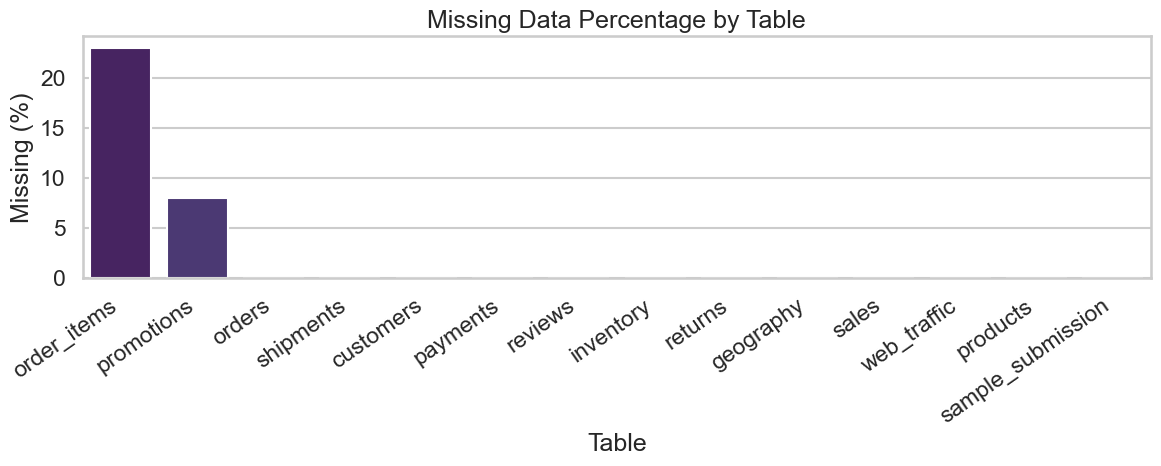

In [4]:
plt.figure(figsize=(12, 5))
plot_df = quality.sort_values('null_pct', ascending=False)
ax = sns.barplot(data=plot_df, x='table', y='null_pct', palette='viridis')
ax.set_title('Missing Data Percentage by Table')
ax.set_xlabel('Table')
ax.set_ylabel('Missing (%)')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_missing_pct_by_table.png', dpi=180)
plt.show()


In [5]:
sales = dfs['sales'].sort_values('Date').copy()
web = dfs['web_traffic'].sort_values('date').copy()
orders = dfs['orders'].sort_values('order_date').copy()
inv = dfs['inventory'].sort_values('snapshot_date').copy()

coverage = pd.DataFrame({
    'dataset': ['sales', 'orders', 'web_traffic', 'inventory'],
    'start': [sales['Date'].min(), orders['order_date'].min(), web['date'].min(), inv['snapshot_date'].min()],
    'end': [sales['Date'].max(), orders['order_date'].max(), web['date'].max(), inv['snapshot_date'].max()],
    'rows': [len(sales), len(orders), len(web), len(inv)],
})
coverage


,dataset,start,end,rows
0,sales,2012-07-04,2022-12-31,3833
1,orders,2012-07-04,2022-12-31,646945
2,web_traffic,2013-01-01,2022-12-31,3652
3,inventory,2012-07-31,2022-12-31,60247


## Sales Trends and Seasonality

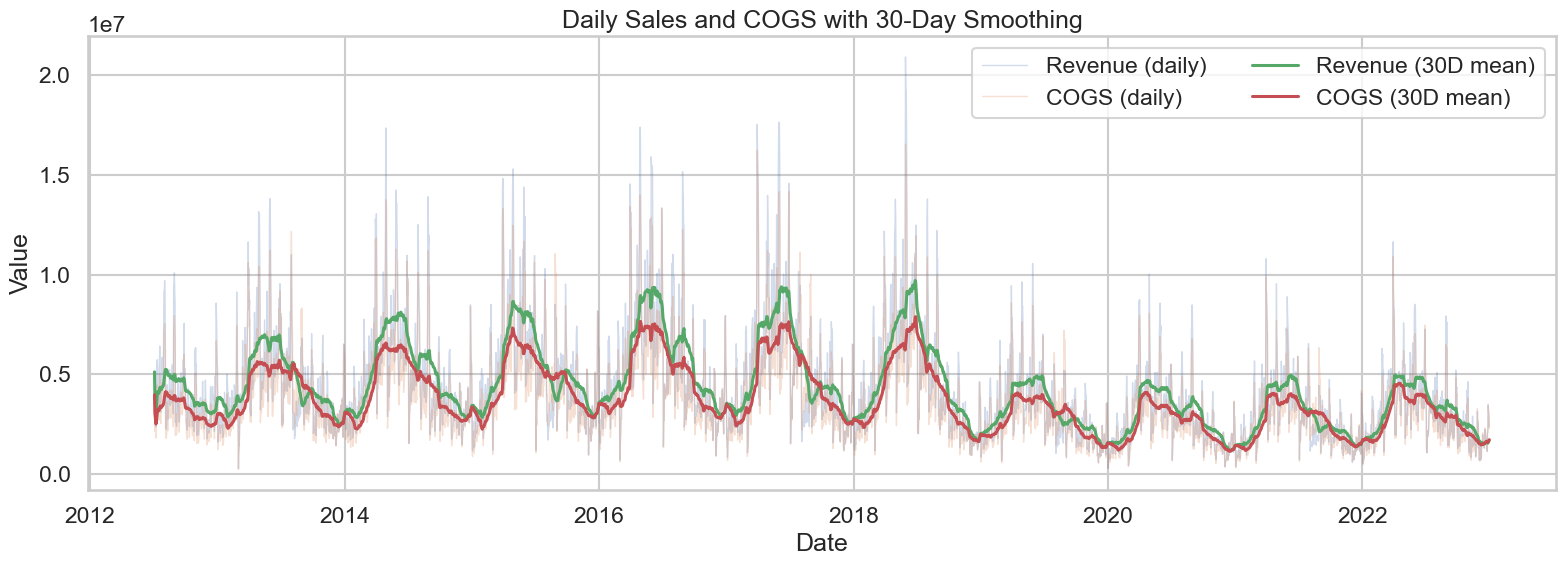

In [6]:
sales['rev_30d'] = sales['Revenue'].rolling(30, min_periods=1).mean()
sales['cogs_30d'] = sales['COGS'].rolling(30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(sales['Date'], sales['Revenue'], alpha=0.25, linewidth=1, label='Revenue (daily)')
ax.plot(sales['Date'], sales['COGS'], alpha=0.25, linewidth=1, label='COGS (daily)')
ax.plot(sales['Date'], sales['rev_30d'], linewidth=2.2, label='Revenue (30D mean)')
ax.plot(sales['Date'], sales['cogs_30d'], linewidth=2.2, label='COGS (30D mean)')
ax.set_title('Daily Sales and COGS with 30-Day Smoothing')
ax.set_xlabel('Date')
ax.set_ylabel('Value')
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_daily_sales_cogs_rolling.png', dpi=180)
plt.show()


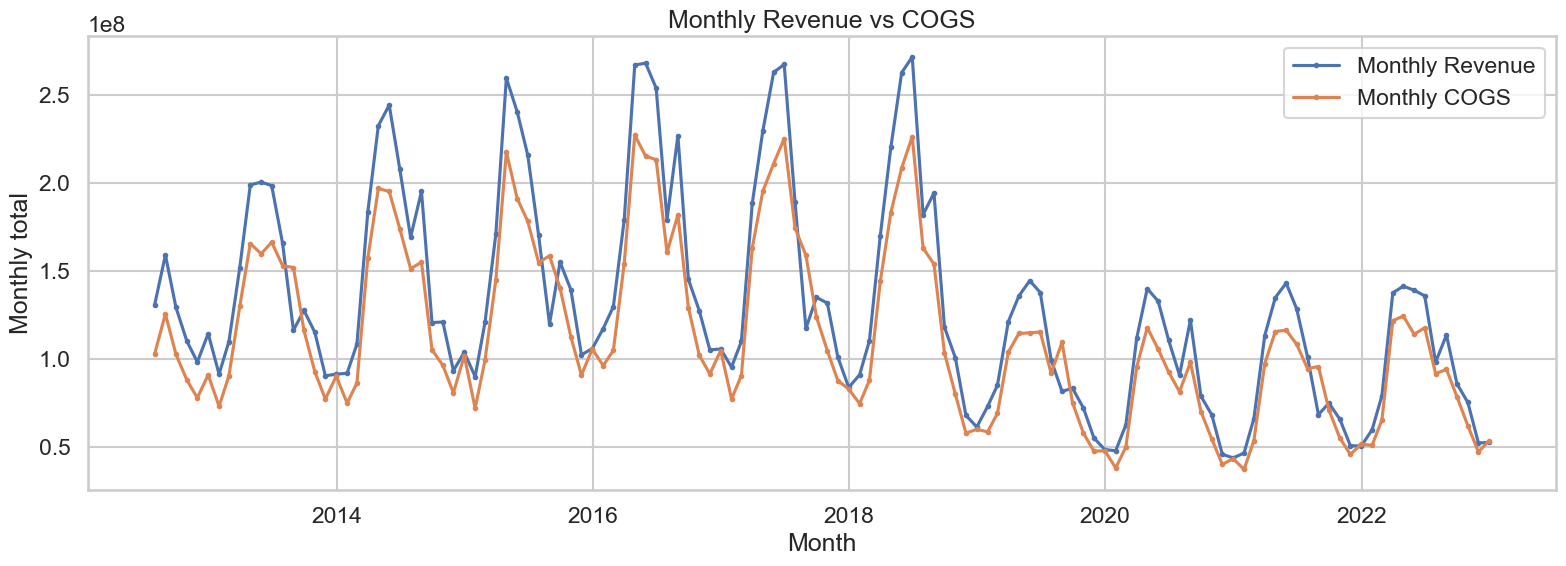

In [7]:
monthly = sales.set_index('Date')[['Revenue', 'COGS']].resample('ME').sum().reset_index()
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(monthly['Date'], monthly['Revenue'], marker='o', markersize=3, label='Monthly Revenue')
ax.plot(monthly['Date'], monthly['COGS'], marker='o', markersize=3, label='Monthly COGS')
ax.set_title('Monthly Revenue vs COGS')
ax.set_xlabel('Month')
ax.set_ylabel('Monthly total')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '03_monthly_revenue_cogs.png', dpi=180)
plt.show()


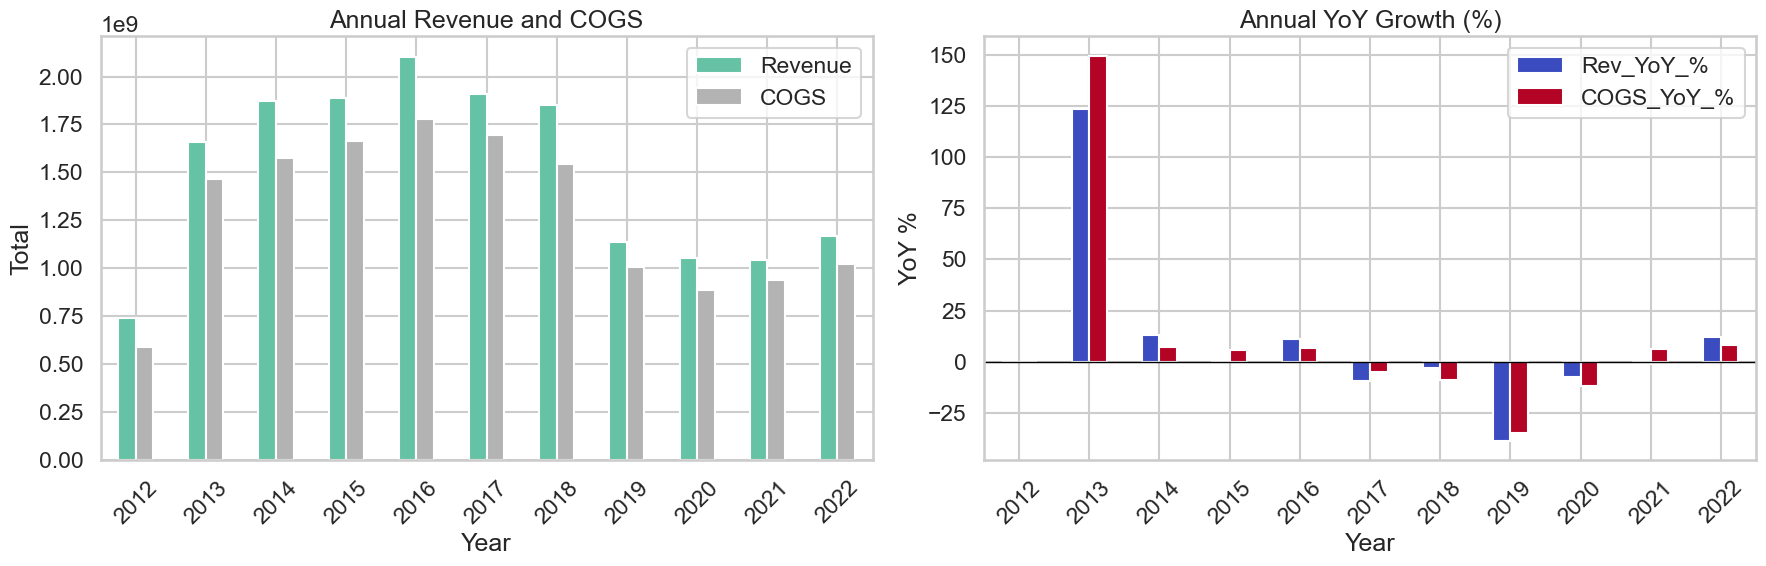

,Revenue,COGS,Rev_YoY_%,COGS_YoY_%
Date,,,,
2013,1.657169e+09,1.465980e+09,123.489474,149.544701
2014,1.871846e+09,1.574607e+09,12.954407,7.409879
2015,1.889934e+09,1.665442e+09,0.966316,5.768699
2016,2.104641e+09,1.780559e+09,11.360549,6.912134
2017,1.911164e+09,1.694386e+09,-9.192845,-4.839692
2018,1.850122e+09,1.542176e+09,-3.193962,-8.983198
2019,1.136801e+09,1.005203e+09,-38.555341,-34.819175
2020,1.054512e+09,8.860851e+08,-7.238668,-11.850124
2021,1.043040e+09,9.411301e+08,-1.087929,6.212160


In [8]:
annual = sales.set_index('Date')[['Revenue', 'COGS']].resample('YE').sum()
annual.index = annual.index.year
annual['Rev_YoY_%'] = annual['Revenue'].pct_change() * 100
annual['COGS_YoY_%'] = annual['COGS'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
annual[['Revenue', 'COGS']].plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Annual Revenue and COGS')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total')
axes[0].tick_params(axis='x', rotation=45)

annual[['Rev_YoY_%', 'COGS_YoY_%']].plot(kind='bar', ax=axes[1], colormap='coolwarm')
axes[1].set_title('Annual YoY Growth (%)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('YoY %')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / '04_annual_levels_and_growth.png', dpi=180)
plt.show()

annual.tail(10)


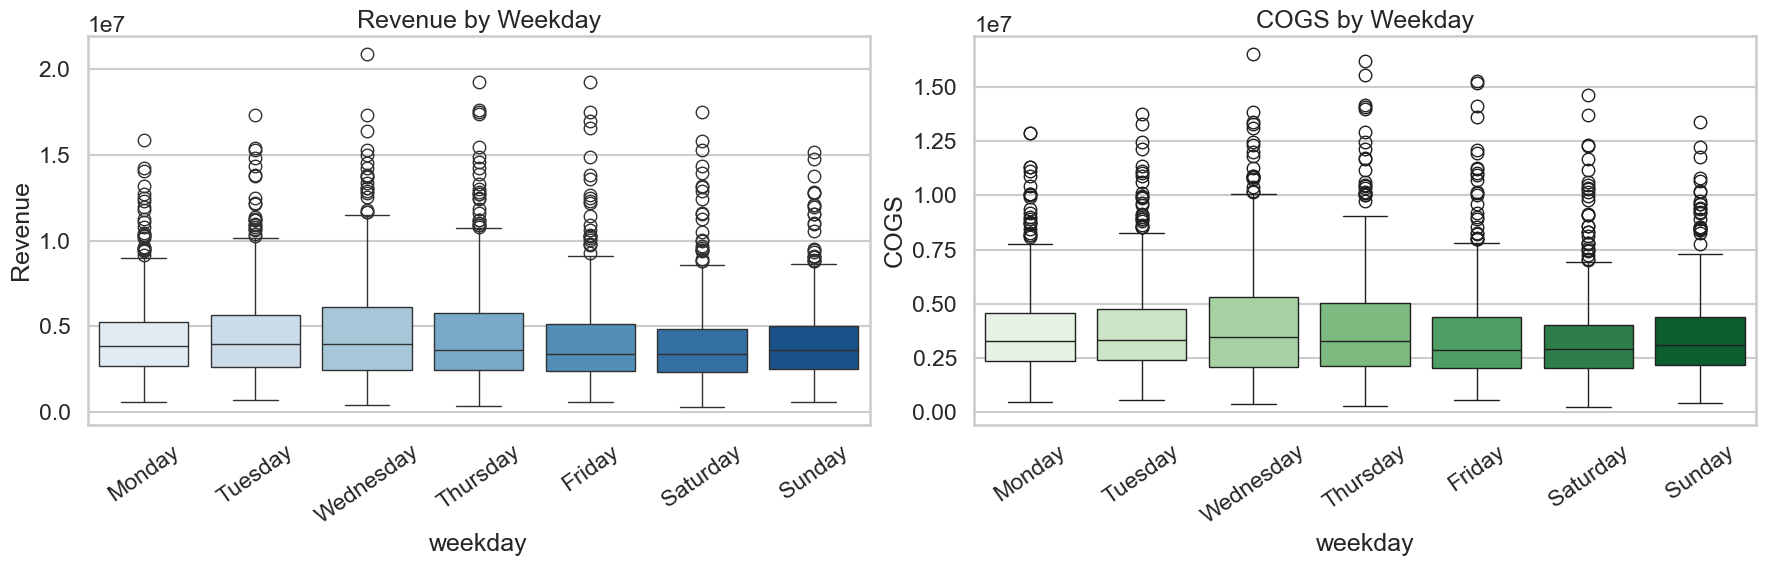

In [9]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sales['weekday'] = sales['Date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=sales, x='weekday', y='Revenue', order=weekday_order, ax=axes[0], palette='Blues')
axes[0].set_title('Revenue by Weekday')
axes[0].tick_params(axis='x', rotation=35)

sns.boxplot(data=sales, x='weekday', y='COGS', order=weekday_order, ax=axes[1], palette='Greens')
axes[1].set_title('COGS by Weekday')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_weekday_boxplots.png', dpi=180)
plt.show()


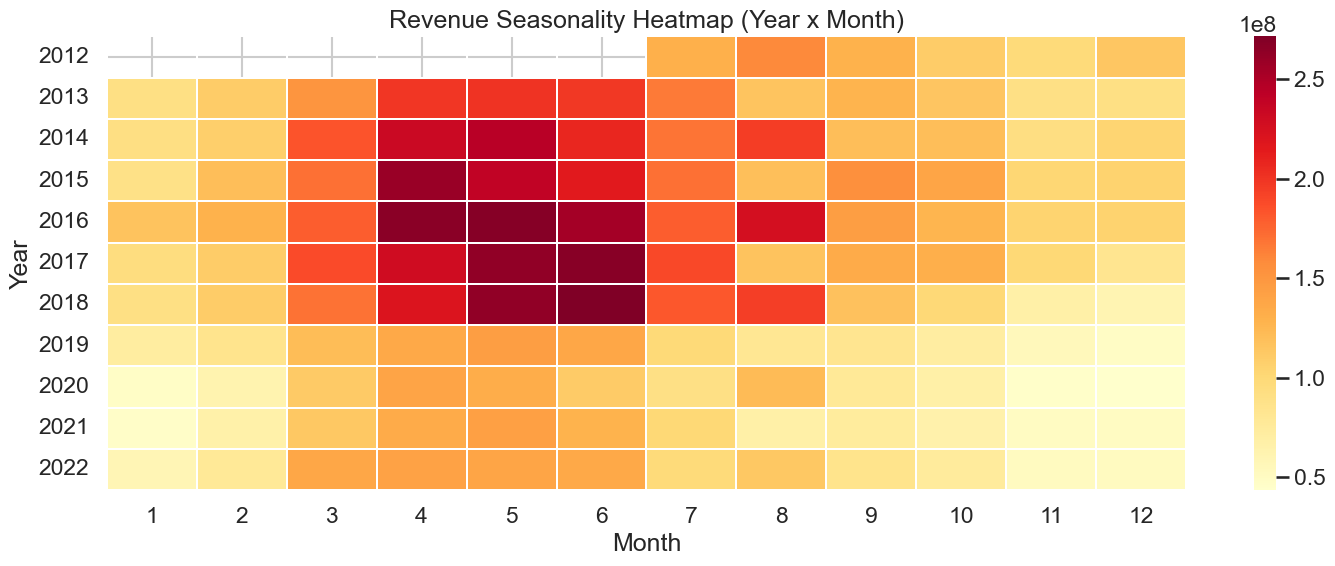

In [10]:
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
heat = sales.pivot_table(index='year', columns='month', values='Revenue', aggfunc='sum')

plt.figure(figsize=(15, 6))
sns.heatmap(heat, cmap='YlOrRd', linewidths=0.3, linecolor='white')
plt.title('Revenue Seasonality Heatmap (Year x Month)')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_revenue_seasonality_heatmap.png', dpi=180)
plt.show()


## Orders, Payments, and Product Mix

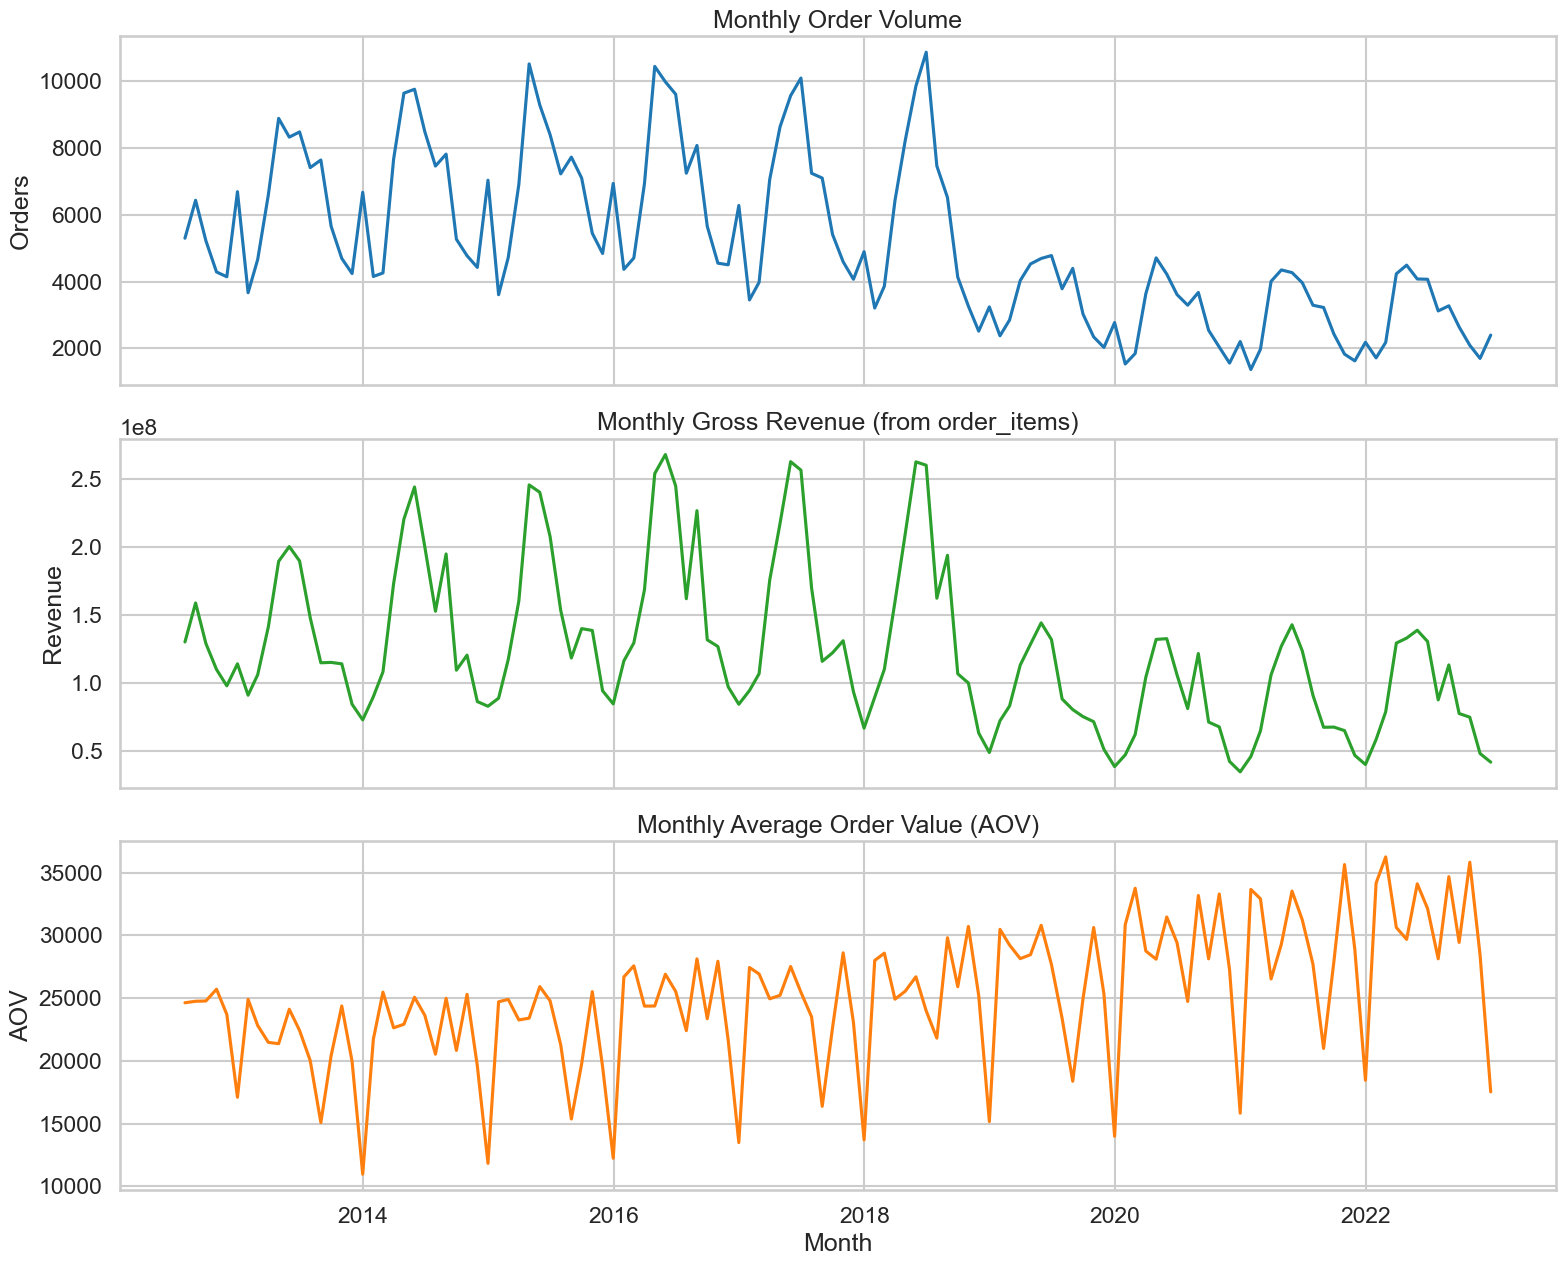

In [11]:
order_items = dfs['order_items'].copy()
order_items['line_revenue'] = order_items['quantity'] * order_items['unit_price'] - order_items['discount_amount']

order_value = order_items.groupby('order_id', as_index=False).agg(
    order_revenue=('line_revenue', 'sum'),
    total_items=('quantity', 'sum')
)

orders_enriched = orders.merge(order_value, on='order_id', how='left')
orders_enriched['order_revenue'] = orders_enriched['order_revenue'].fillna(0.0)

orders_monthly = orders_enriched.set_index('order_date').resample('ME').agg(
    orders=('order_id', 'nunique'),
    gross_revenue=('order_revenue', 'sum'),
    aov=('order_revenue', 'mean')
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
axes[0].plot(orders_monthly['order_date'], orders_monthly['orders'], color='#1f77b4')
axes[0].set_title('Monthly Order Volume')
axes[0].set_ylabel('Orders')

axes[1].plot(orders_monthly['order_date'], orders_monthly['gross_revenue'], color='#2ca02c')
axes[1].set_title('Monthly Gross Revenue (from order_items)')
axes[1].set_ylabel('Revenue')

axes[2].plot(orders_monthly['order_date'], orders_monthly['aov'], color='#ff7f0e')
axes[2].set_title('Monthly Average Order Value (AOV)')
axes[2].set_ylabel('AOV')
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.savefig(FIG_DIR / '07_orders_revenue_aov_monthly.png', dpi=180)
plt.show()


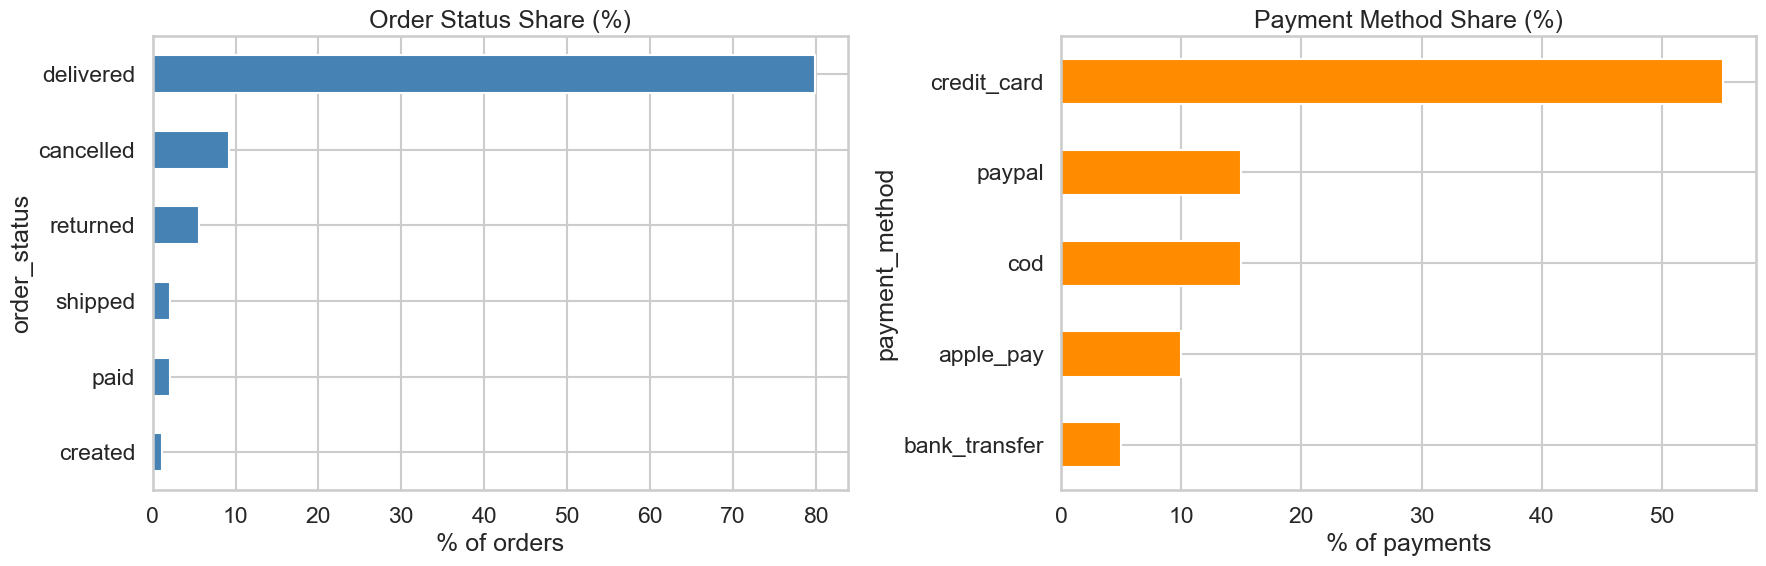

(order_status
 created       1.124516
 paid          2.098633
 shipped       2.128929
 returned      5.586565
 cancelled     9.191199
 delivered    79.870159
 Name: proportion, dtype: float64,
 payment_method
 bank_transfer     4.966574
 apple_pay        10.010588
 cod              14.944238
 paypal           14.996329
 credit_card      55.082271
 Name: proportion, dtype: float64)

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

status_share = orders['order_status'].value_counts(normalize=True).mul(100).sort_values(ascending=True)
status_share.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Order Status Share (%)')
axes[0].set_xlabel('% of orders')

payment_share = dfs['payments']['payment_method'].value_counts(normalize=True).mul(100).sort_values(ascending=True)
payment_share.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Payment Method Share (%)')
axes[1].set_xlabel('% of payments')

plt.tight_layout()
plt.savefig(FIG_DIR / '08_order_status_payment_mix.png', dpi=180)
plt.show()

status_share, payment_share


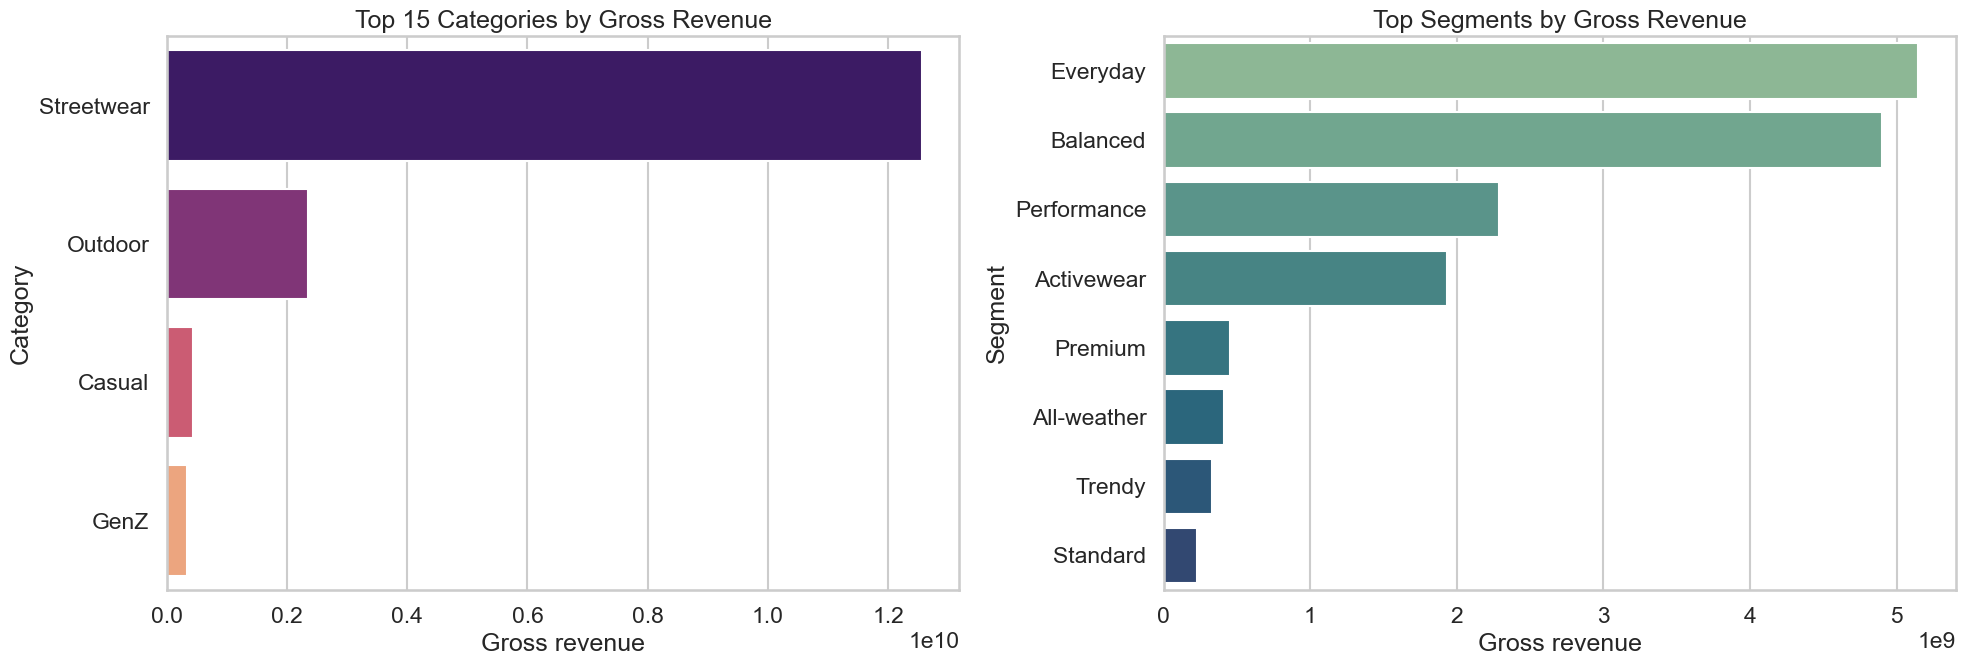

In [13]:
products = dfs['products'][['product_id', 'category', 'segment']].copy()
item_products = order_items.merge(products, on='product_id', how='left')

cat_rev = item_products.groupby('category', as_index=False)['line_revenue'].sum().sort_values('line_revenue', ascending=False)
seg_rev = item_products.groupby('segment', as_index=False)['line_revenue'].sum().sort_values('line_revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.barplot(data=cat_rev.head(15), y='category', x='line_revenue', ax=axes[0], palette='magma')
axes[0].set_title('Top 15 Categories by Gross Revenue')
axes[0].set_xlabel('Gross revenue')
axes[0].set_ylabel('Category')

sns.barplot(data=seg_rev.head(12), y='segment', x='line_revenue', ax=axes[1], palette='crest')
axes[1].set_title('Top Segments by Gross Revenue')
axes[1].set_xlabel('Gross revenue')
axes[1].set_ylabel('Segment')

plt.tight_layout()
plt.savefig(FIG_DIR / '09_category_segment_revenue.png', dpi=180)
plt.show()


## Returns and Reviews

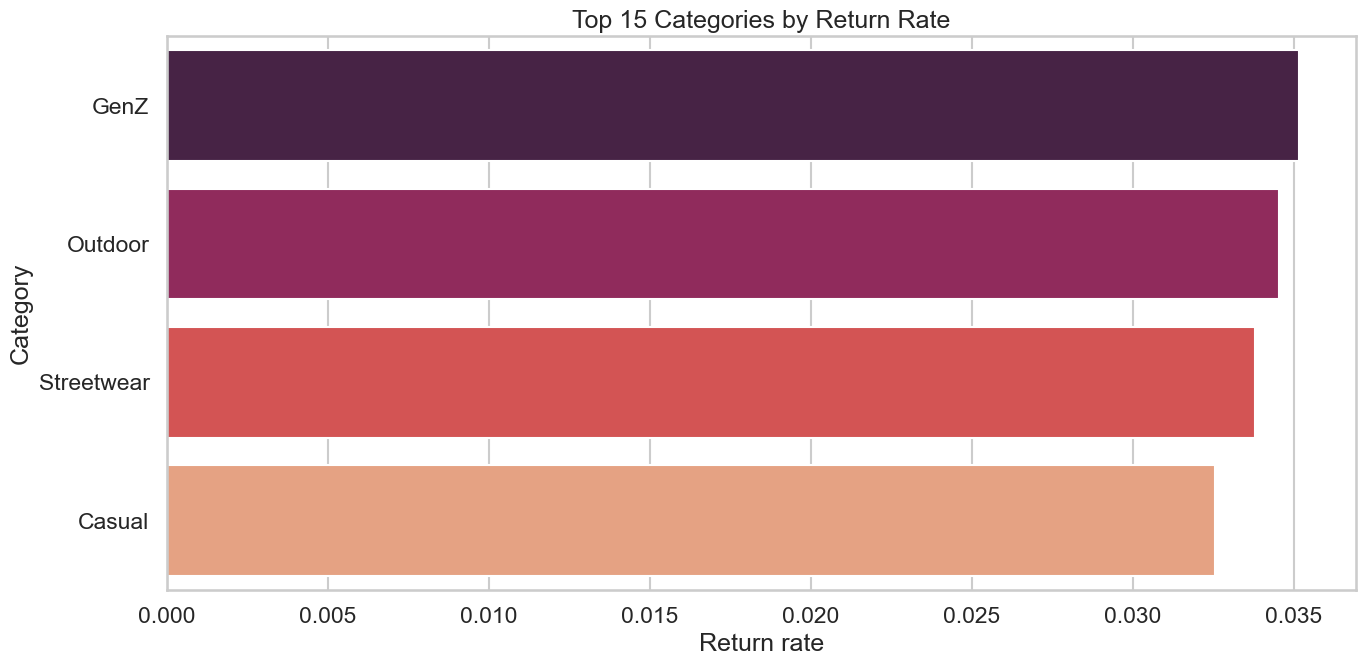

,category,units_sold,units_returned,return_rate
1,GenZ,166848,5869.0,0.035176
2,Outdoor,1170000,40417.0,0.034544
3,Streetwear,1768826,59801.0,0.033808
0,Casual,107469,3499.0,0.032558


In [14]:
returns = dfs['returns'][['product_id', 'return_quantity']].copy()

sold_qty = order_items.groupby('product_id', as_index=False)['quantity'].sum().rename(columns={'quantity': 'units_sold'})
ret_qty = returns.groupby('product_id', as_index=False)['return_quantity'].sum().rename(columns={'return_quantity': 'units_returned'})

ret = sold_qty.merge(ret_qty, on='product_id', how='left').fillna({'units_returned': 0})
ret['return_rate'] = ret['units_returned'] / ret['units_sold'].clip(lower=1)
ret = ret.merge(products, on='product_id', how='left')

cat_ret = ret.groupby('category', as_index=False).agg(
    units_sold=('units_sold', 'sum'),
    units_returned=('units_returned', 'sum')
)
cat_ret['return_rate'] = cat_ret['units_returned'] / cat_ret['units_sold'].clip(lower=1)
cat_ret = cat_ret.sort_values('return_rate', ascending=False)

plt.figure(figsize=(14, 7))
sns.barplot(data=cat_ret.head(15), y='category', x='return_rate', palette='rocket')
plt.title('Top 15 Categories by Return Rate')
plt.xlabel('Return rate')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(FIG_DIR / '10_category_return_rate.png', dpi=180)
plt.show()

cat_ret.head(10)


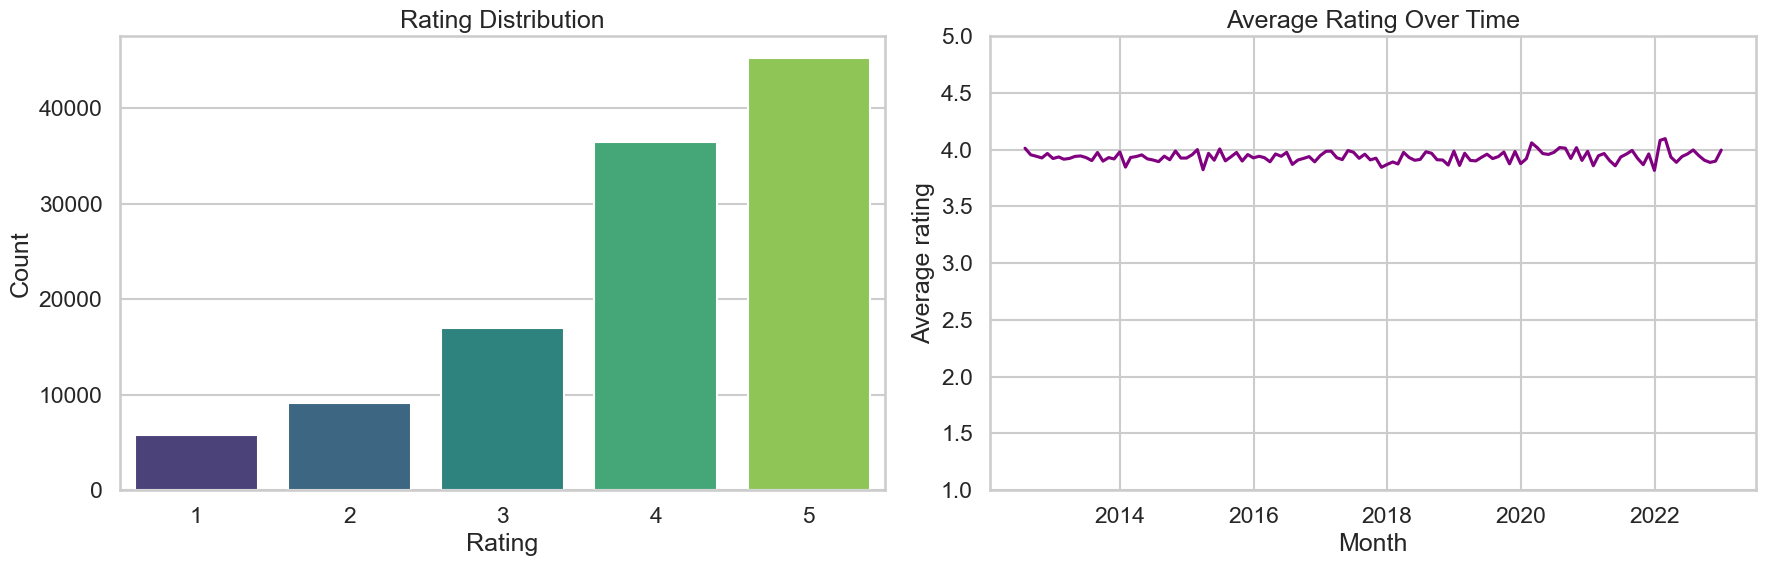

In [15]:
reviews = dfs['reviews'].copy()
reviews['rating'] = pd.to_numeric(reviews['rating'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(data=reviews, x='rating', ax=axes[0], palette='viridis')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

monthly_rating = reviews.set_index('review_date')['rating'].resample('ME').mean().reset_index()
axes[1].plot(monthly_rating['review_date'], monthly_rating['rating'], color='purple')
axes[1].set_title('Average Rating Over Time')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average rating')
axes[1].set_ylim(1, 5)

plt.tight_layout()
plt.savefig(FIG_DIR / '11_reviews_distribution_trend.png', dpi=180)
plt.show()


## Customer and Geography Signals

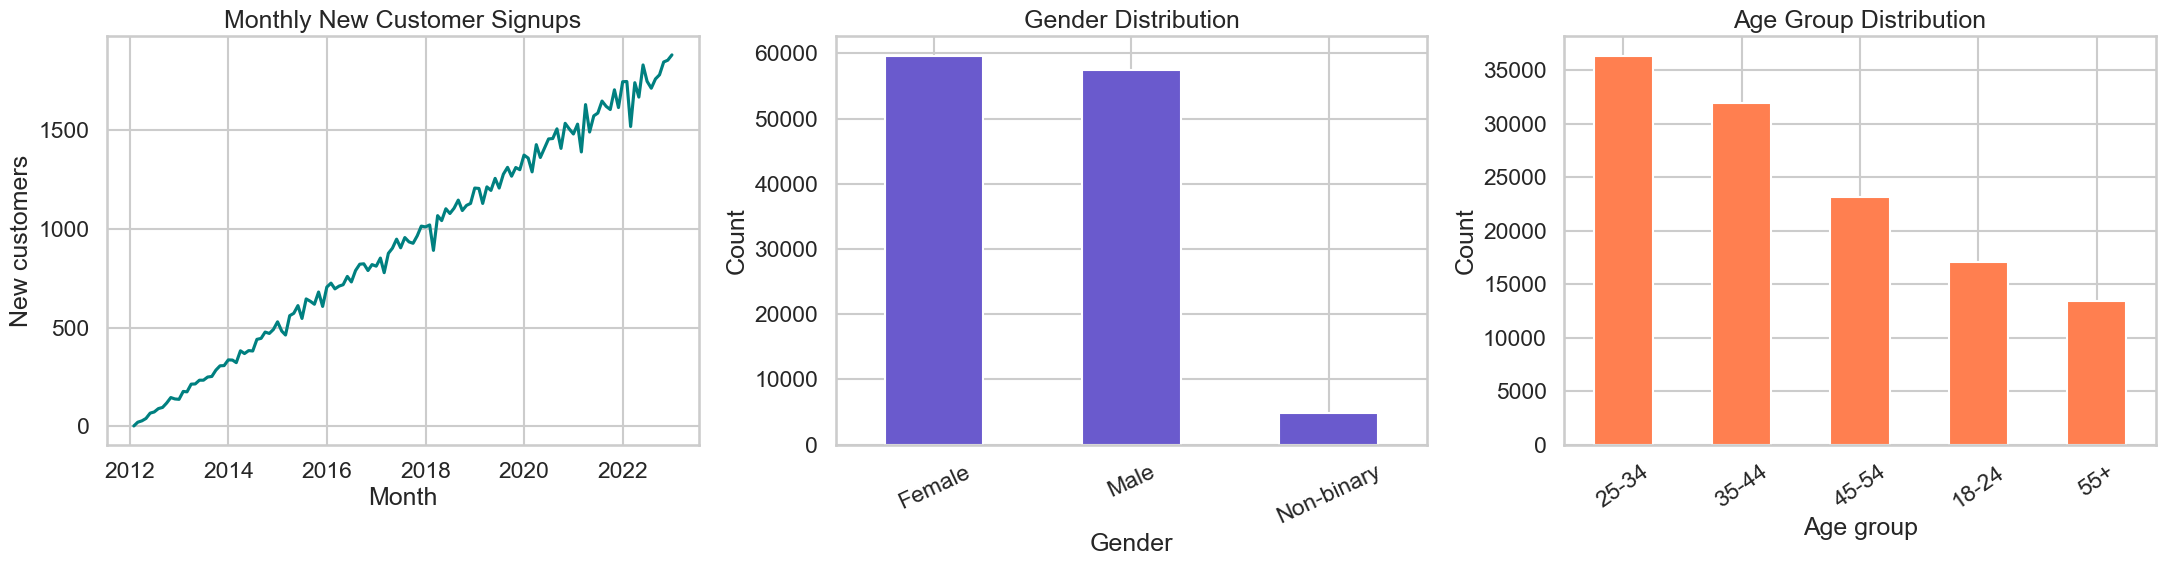

In [16]:
customers = dfs['customers'].copy()

signup_monthly = customers.set_index('signup_date').resample('ME')['customer_id'].nunique().reset_index(name='new_customers')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].plot(signup_monthly['signup_date'], signup_monthly['new_customers'], color='teal')
axes[0].set_title('Monthly New Customer Signups')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('New customers')

gender_counts = customers['gender'].fillna('Unknown').value_counts()
gender_counts.plot(kind='bar', ax=axes[1], color='slateblue')
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=25)

age_counts = customers['age_group'].fillna('Unknown').value_counts()
age_counts.plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_title('Age Group Distribution')
axes[2].set_xlabel('Age group')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig(FIG_DIR / '12_customer_signup_demographics.png', dpi=180)
plt.show()


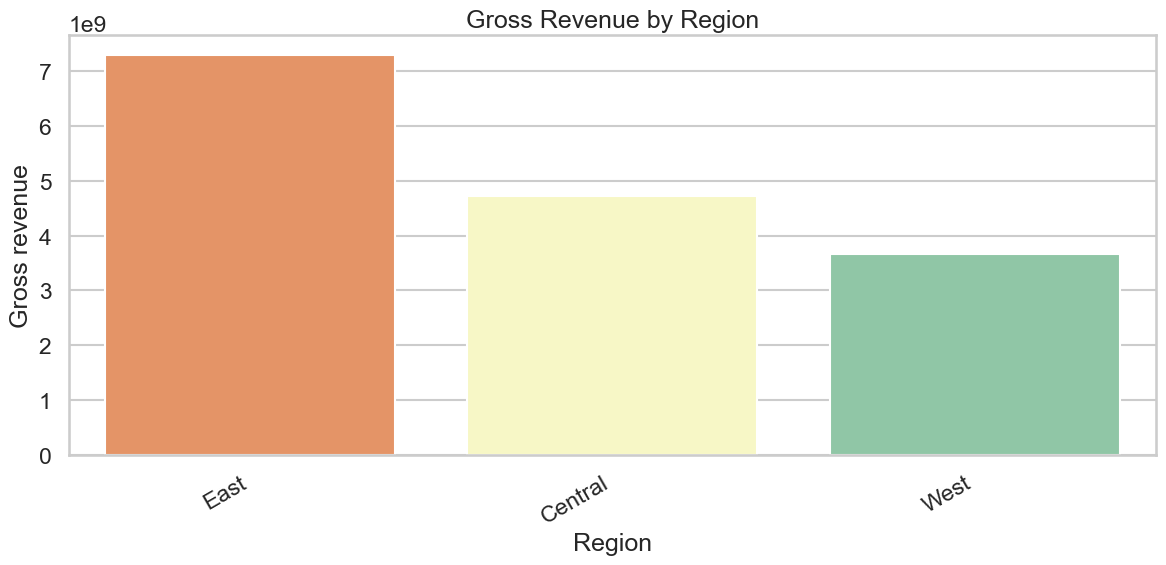

,region,order_revenue
1,East,7.291151e+09
0,Central,4.719491e+09
2,West,3.670227e+09


In [17]:
geo = dfs['geography'][['zip', 'region']].drop_duplicates()
orders_geo = orders_enriched[['order_id', 'zip', 'order_revenue']].merge(geo, on='zip', how='left')
region_rev = orders_geo.groupby('region', as_index=False)['order_revenue'].sum().sort_values('order_revenue', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=region_rev, x='region', y='order_revenue', palette='Spectral')
plt.title('Gross Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Gross revenue')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '13_region_revenue.png', dpi=180)
plt.show()

region_rev


## Inventory and Logistics

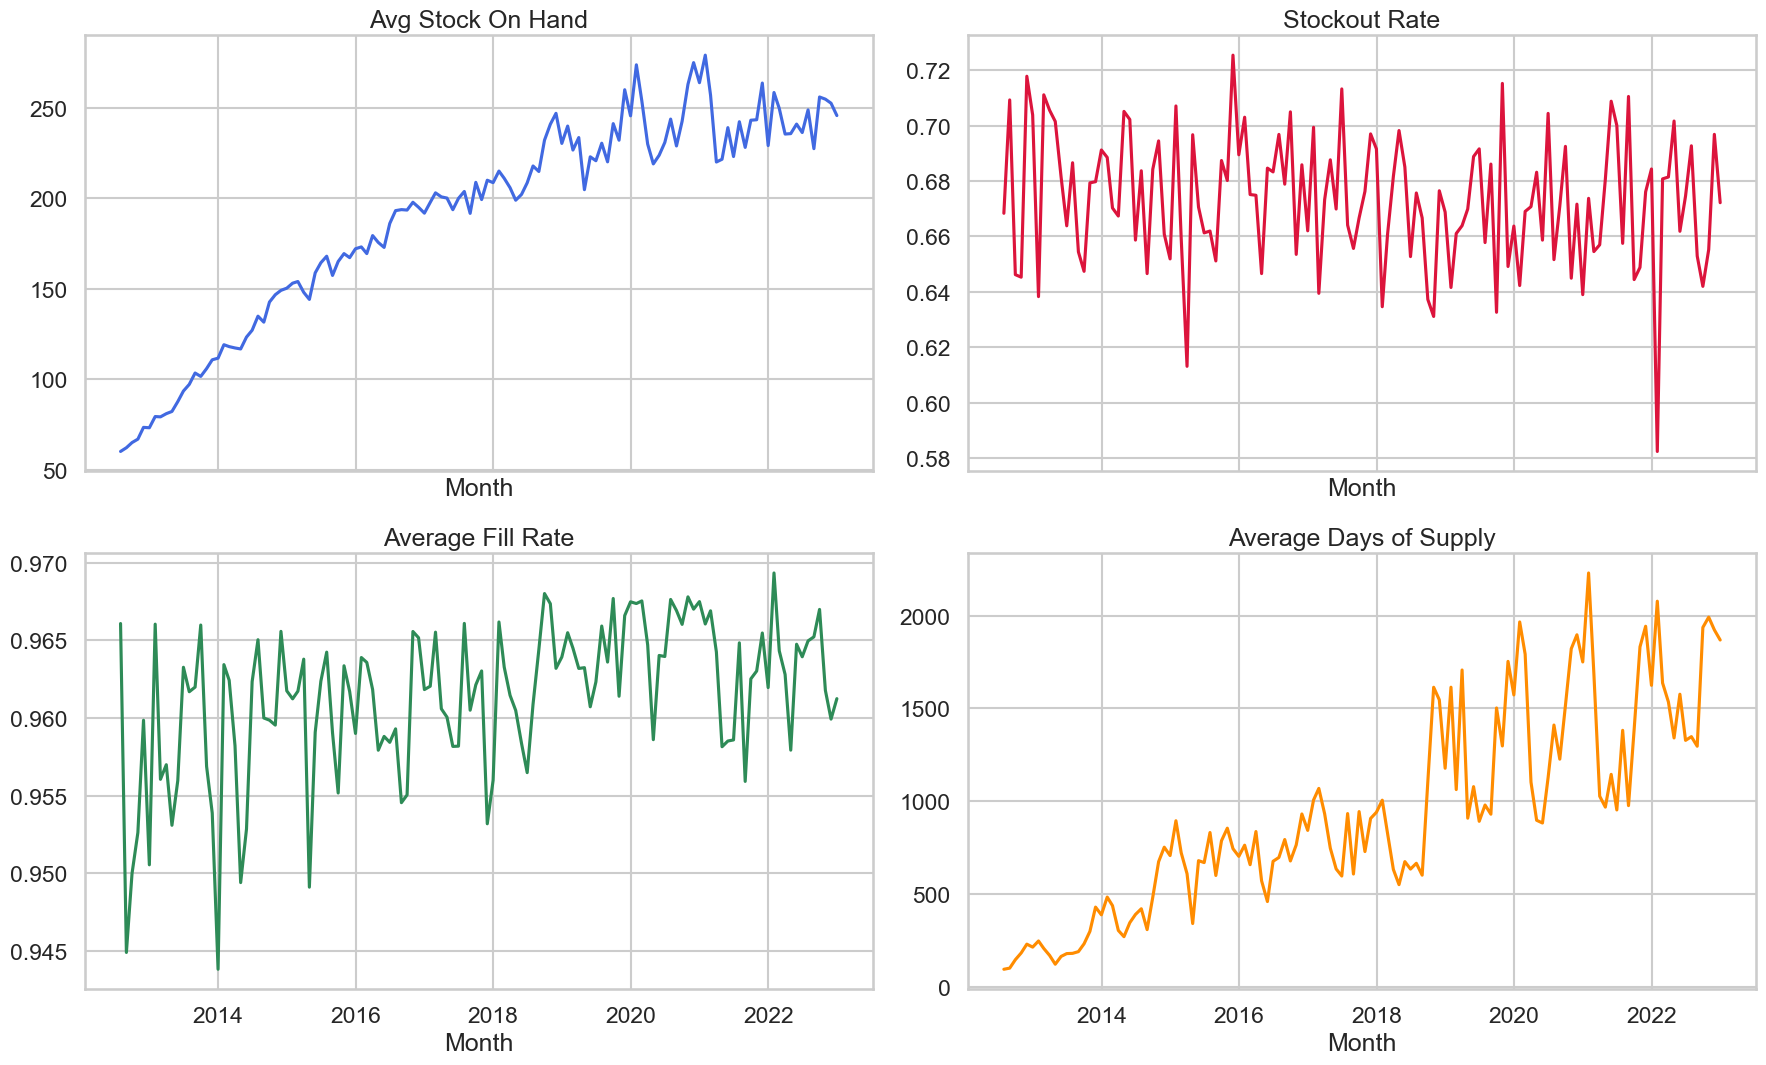

In [18]:
inv_monthly = inv.set_index('snapshot_date').resample('ME').agg(
    avg_stock_on_hand=('stock_on_hand', 'mean'),
    stockout_rate=('stockout_flag', 'mean'),
    avg_fill_rate=('fill_rate', 'mean'),
    avg_days_supply=('days_of_supply', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 11), sharex=True)

axes[0,0].plot(inv_monthly['snapshot_date'], inv_monthly['avg_stock_on_hand'], color='royalblue')
axes[0,0].set_title('Avg Stock On Hand')

axes[0,1].plot(inv_monthly['snapshot_date'], inv_monthly['stockout_rate'], color='crimson')
axes[0,1].set_title('Stockout Rate')

axes[1,0].plot(inv_monthly['snapshot_date'], inv_monthly['avg_fill_rate'], color='seagreen')
axes[1,0].set_title('Average Fill Rate')

axes[1,1].plot(inv_monthly['snapshot_date'], inv_monthly['avg_days_supply'], color='darkorange')
axes[1,1].set_title('Average Days of Supply')

for ax in axes.ravel():
    ax.set_xlabel('Month')

plt.tight_layout()
plt.savefig(FIG_DIR / '14_inventory_monthly_trends.png', dpi=180)
plt.show()


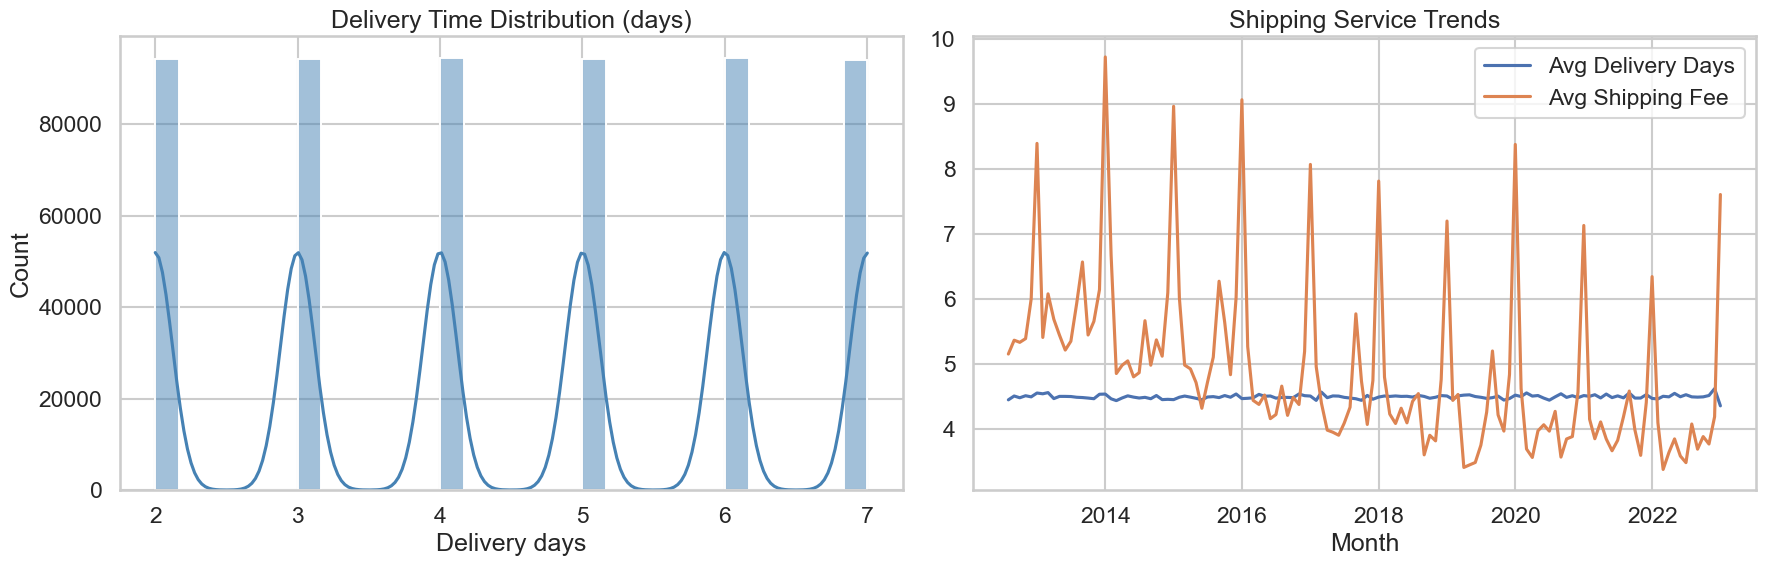

In [19]:
ship = dfs['shipments'].copy()
ship['delivery_days'] = (ship['delivery_date'] - ship['ship_date']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(ship['delivery_days'].dropna(), bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Delivery Time Distribution (days)')
axes[0].set_xlabel('Delivery days')

ship_monthly = ship.set_index('ship_date').resample('ME').agg(
    avg_delivery_days=('delivery_days', 'mean'),
    avg_shipping_fee=('shipping_fee', 'mean')
).reset_index()

axes[1].plot(ship_monthly['ship_date'], ship_monthly['avg_delivery_days'], label='Avg Delivery Days')
axes[1].plot(ship_monthly['ship_date'], ship_monthly['avg_shipping_fee'], label='Avg Shipping Fee')
axes[1].set_title('Shipping Service Trends')
axes[1].set_xlabel('Month')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '15_shipping_delivery_analysis.png', dpi=180)
plt.show()


## Web Traffic and Sales Relationship

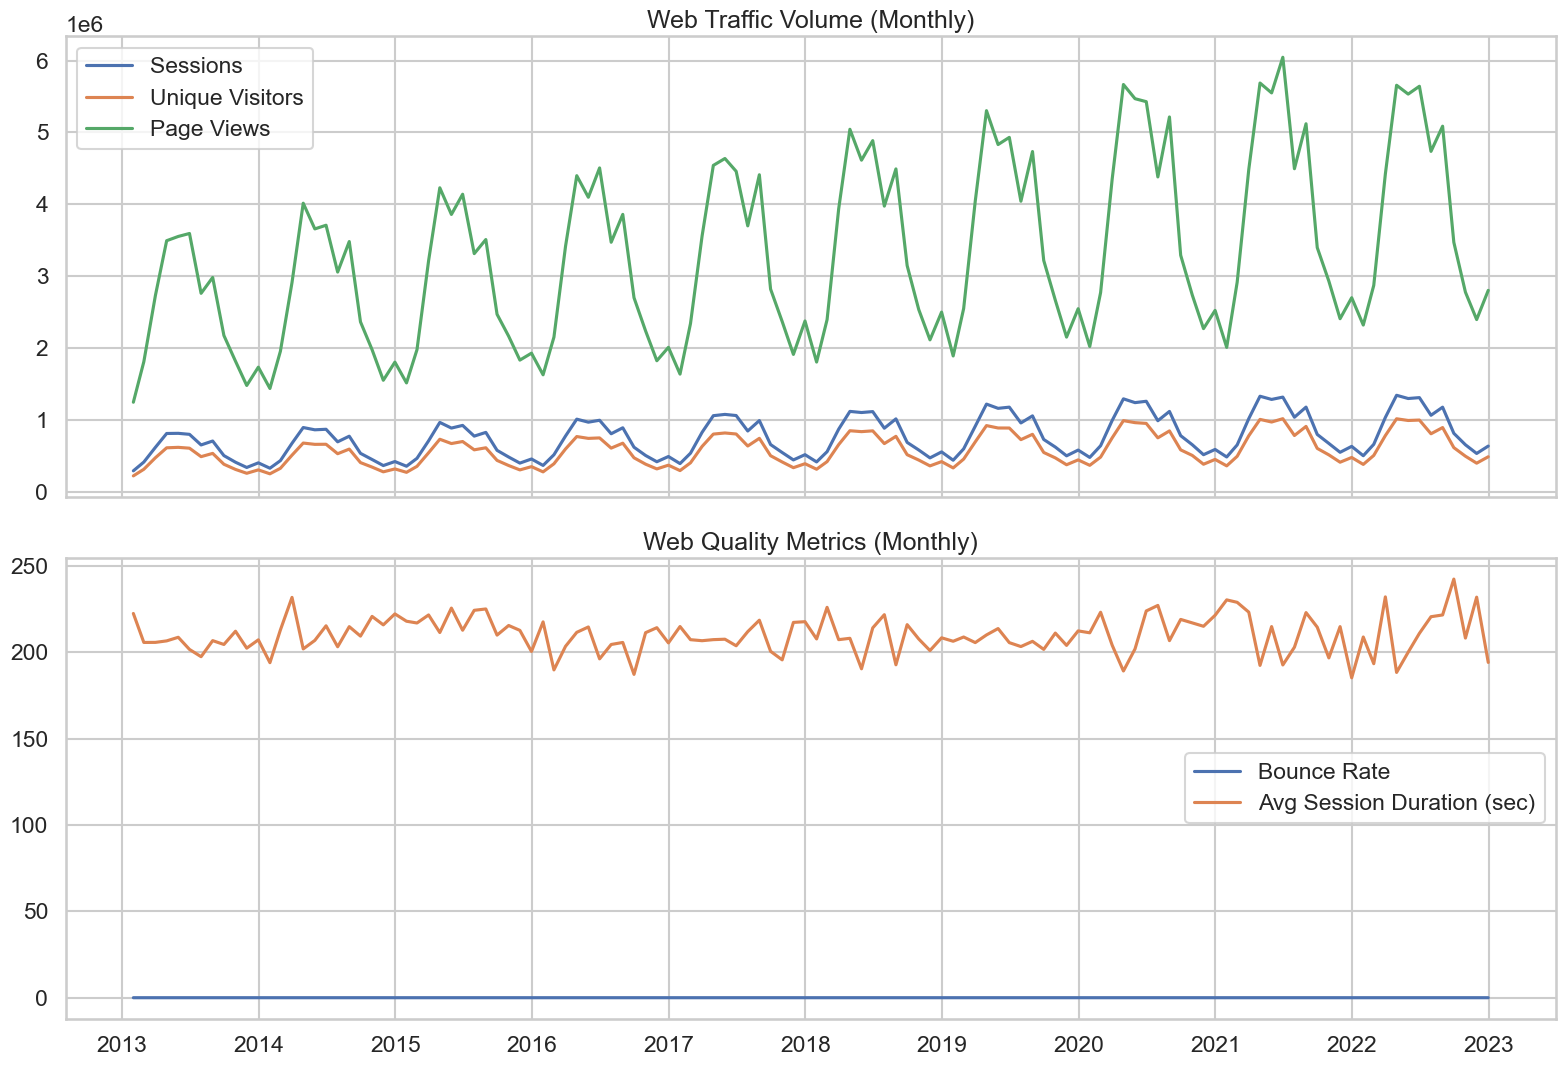

In [20]:
web_monthly = web.set_index('date').resample('ME').agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
    bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration_sec=('avg_session_duration_sec', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
axes[0].plot(web_monthly['date'], web_monthly['sessions'], label='Sessions')
axes[0].plot(web_monthly['date'], web_monthly['unique_visitors'], label='Unique Visitors')
axes[0].plot(web_monthly['date'], web_monthly['page_views'], label='Page Views')
axes[0].set_title('Web Traffic Volume (Monthly)')
axes[0].legend()

axes[1].plot(web_monthly['date'], web_monthly['bounce_rate'], label='Bounce Rate')
axes[1].plot(web_monthly['date'], web_monthly['avg_session_duration_sec'], label='Avg Session Duration (sec)')
axes[1].set_title('Web Quality Metrics (Monthly)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '16_web_monthly_trends.png', dpi=180)
plt.show()


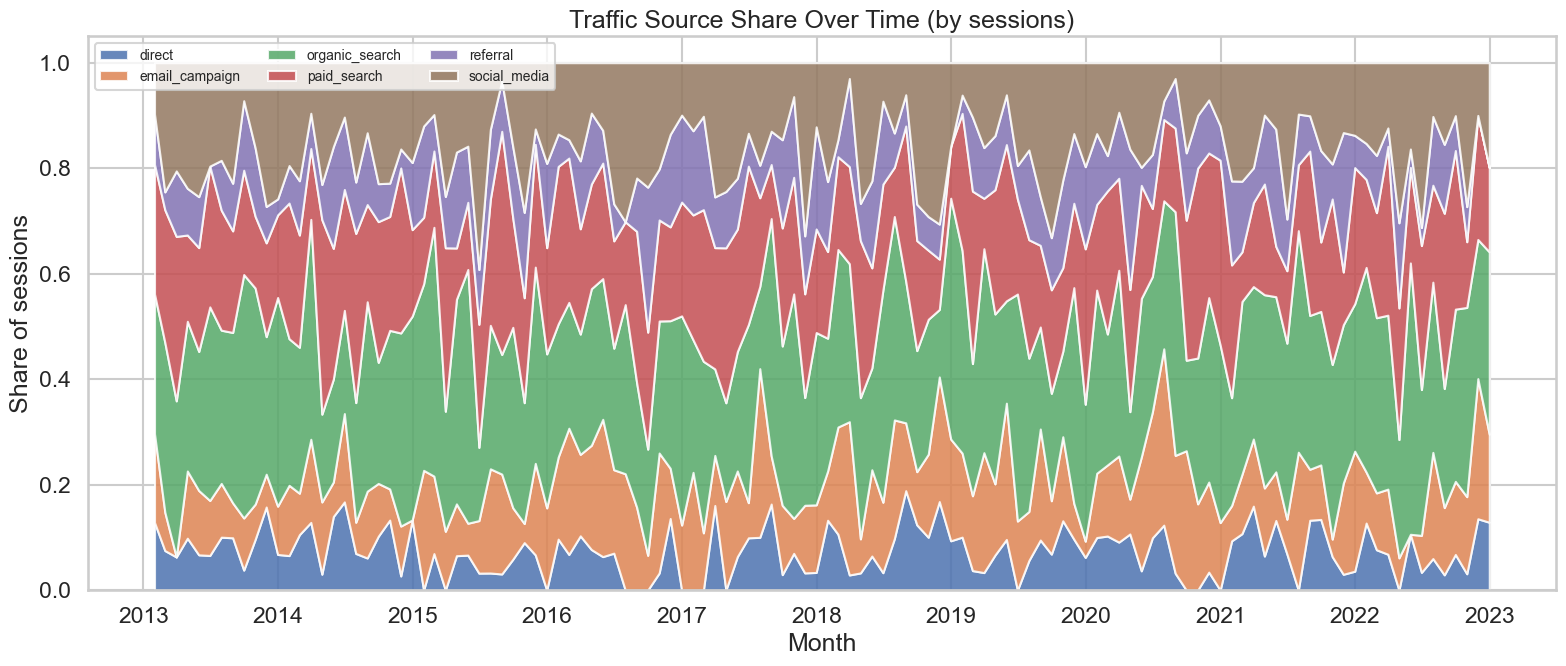

In [21]:
src_mix = web.groupby([pd.Grouper(key='date', freq='ME'), 'traffic_source'])['sessions'].sum().unstack(fill_value=0)
src_share = src_mix.div(src_mix.sum(axis=1), axis=0)

plt.figure(figsize=(16, 7))
plt.stackplot(src_share.index, src_share.T, labels=src_share.columns, alpha=0.85)
plt.legend(loc='upper left', ncol=3, fontsize=10)
plt.title('Traffic Source Share Over Time (by sessions)')
plt.xlabel('Month')
plt.ylabel('Share of sessions')
plt.tight_layout()
plt.savefig(FIG_DIR / '17_traffic_source_share.png', dpi=180)
plt.show()


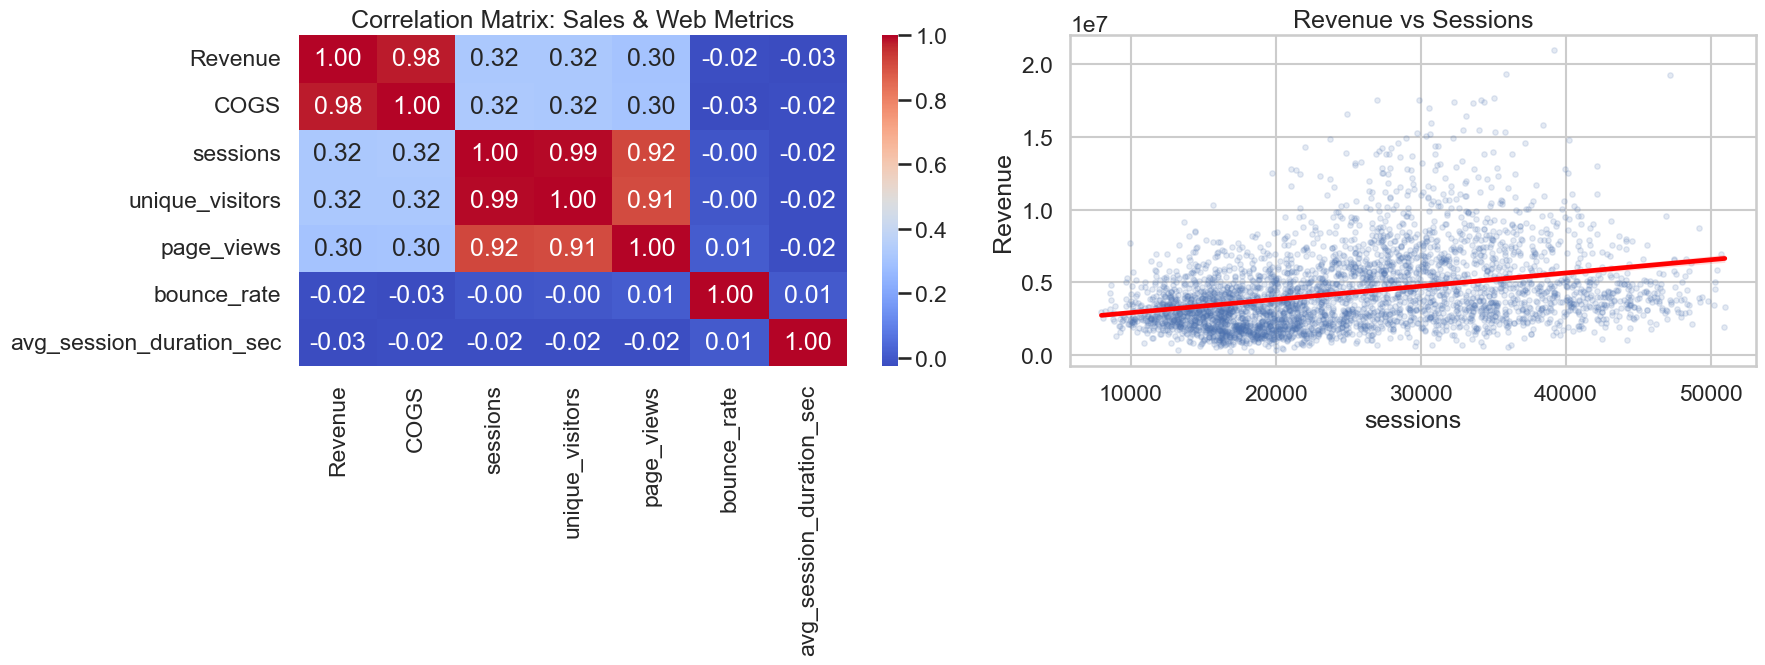

,Revenue,COGS,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec
Revenue,1.000000,0.975994,0.321050,0.318787,0.301573,-0.020551,-0.025622
COGS,0.975994,1.000000,0.323547,0.320150,0.303177,-0.027121,-0.022391
sessions,0.321050,0.323547,1.000000,0.992026,0.919589,-0.004614,-0.022047
unique_visitors,0.318787,0.320150,0.992026,1.000000,0.911411,-0.001950,-0.022504
page_views,0.301573,0.303177,0.919589,0.911411,1.000000,0.010369,-0.022882
bounce_rate,-0.020551,-0.027121,-0.004614,-0.001950,0.010369,1.000000,0.006570
avg_session_duration_sec,-0.025622,-0.022391,-0.022047,-0.022504,-0.022882,0.006570,1.000000


In [22]:
web_daily = web[['date','sessions','unique_visitors','page_views','bounce_rate','avg_session_duration_sec']].copy()
web_daily = web_daily.rename(columns={'date': 'Date'})

sales_web = sales[['Date','Revenue','COGS']].merge(web_daily, on='Date', how='left')

corr_cols = ['Revenue', 'COGS', 'sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']
corr = sales_web[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0])
axes[0].set_title('Correlation Matrix: Sales & Web Metrics')

sns.regplot(data=sales_web, x='sessions', y='Revenue', scatter_kws={'alpha':0.15, 's':15}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Revenue vs Sessions')

plt.tight_layout()
plt.savefig(FIG_DIR / '18_sales_web_correlation.png', dpi=180)
plt.show()

corr


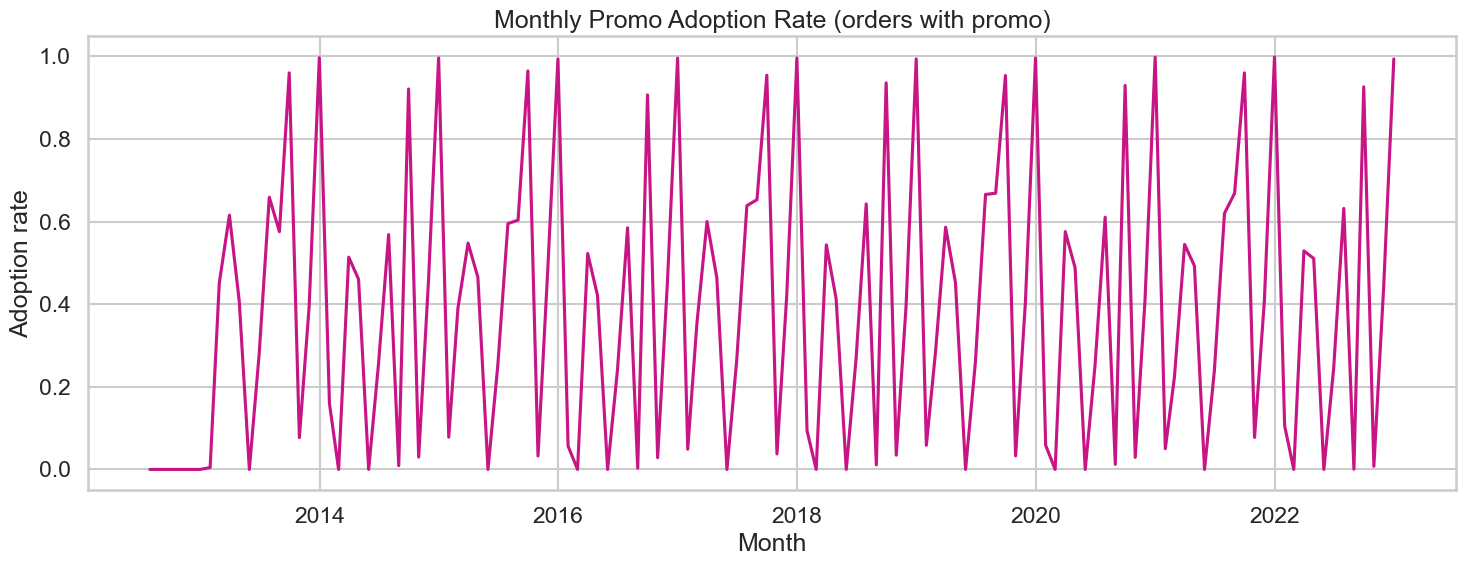

In [23]:
promo_flag = order_items[['order_id', 'promo_id', 'promo_id_2']].copy()
promo_flag['used_promo'] = promo_flag[['promo_id', 'promo_id_2']].notna().any(axis=1).astype(int)

promo_order = promo_flag.groupby('order_id', as_index=False)['used_promo'].max()
promo_month = orders[['order_id', 'order_date']].merge(promo_order, on='order_id', how='left')
promo_month['used_promo'] = promo_month['used_promo'].fillna(0)
promo_monthly = promo_month.set_index('order_date').resample('ME')['used_promo'].mean().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(promo_monthly['order_date'], promo_monthly['used_promo'], color='mediumvioletred')
plt.title('Monthly Promo Adoption Rate (orders with promo)')
plt.xlabel('Month')
plt.ylabel('Adoption rate')
plt.tight_layout()
plt.savefig(FIG_DIR / '19_promo_adoption_rate.png', dpi=180)
plt.show()


## Compact Findings

In [24]:
insights = {}
insights['train_sales_range'] = f"{sales['Date'].min().date()} -> {sales['Date'].max().date()}"
insights['mean_daily_revenue'] = round(float(sales['Revenue'].mean()), 2)
insights['mean_daily_cogs'] = round(float(sales['COGS'].mean()), 2)
insights['latest_year_revenue'] = round(float(annual.loc[annual.index.max(), 'Revenue']), 2)
insights['latest_year_yoy_revenue_pct'] = round(float(annual.loc[annual.index.max(), 'Rev_YoY_%']), 2)
insights['best_category_by_gross_revenue'] = str(cat_rev.iloc[0]['category'])
insights['highest_return_rate_category'] = str(cat_ret.iloc[0]['category'])
insights['avg_delivery_days'] = round(float(ship['delivery_days'].mean()), 2)
insights['corr_revenue_sessions'] = round(float(corr.loc['Revenue', 'sessions']), 3)
insights['avg_monthly_promo_adoption'] = round(float(promo_monthly['used_promo'].mean()), 3)

pd.Series(insights, name='value').to_frame()


,value
train_sales_range,2012-07-04 -> 2022-12-31
mean_daily_revenue,4286584.03
mean_daily_cogs,3695134.49
latest_year_revenue,1169748831.69
latest_year_yoy_revenue_pct,12.15
best_category_by_gross_revenue,Streetwear
highest_return_rate_category,GenZ
avg_delivery_days,4.5
corr_revenue_sessions,0.321
avg_monthly_promo_adoption,0.386
